<a href="https://colab.research.google.com/github/chrispchen/ChenHypoxia/blob/main/scRNA-seq%20analysis/CellTypeAnnotations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cell-type Annotation

## Normoxia leiden clustering

In this section: further processing, normalization, PC, and leiden clustering. This clustering will be used to define the normoxic cell types present in the analysis.

To save this notebook on github, many outputs had to be removed to save memory

### Load into AnnData


In [ ]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive/')
data_path = '/content/drive/MyDrive/Chris/All/'  #change dir to your project folder

Mounted at /content/drive/


### Environment Setup


In [ ]:
# print python version to screen
!python --version

# pip install software
!pip install -q scanpy leidenalg==0.8.10 harmonypy==0.0.9 scrublet==0.2.3 pydeseq2 adjustText
!wget -qc https://raw.githubusercontent.com/wagnerde/scTools-py/master/scTools_dew.py

# import python packages
import scanpy as sc
import os, sys
import numpy as np
import pandas as pd

import scTools_dew as dew
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

# set some ScanPy settings
sc.set_figure_params(dpi=120, figsize=[4,4], fontsize=7)
sc.settings.verbosity = 0

Python 3.12.13
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 18.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 20.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 38.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

### Load h5ad

In [ ]:
# Load in preprocessed h5ad
adata = sc.read(data_path + 'h5ad/Preprocessed.h5ad')

In [ ]:
# get only normoxia time points

OfInterst = ["Normoxia_6hpf_WT", "Normoxia_8hpf_WT", "Normoxia_10hpf_WT"]
sliceindex = adata.obs['Group'].isin(OfInterst)
adata = adata[sliceindex].copy()
adata

AnnData object with n_obs × n_vars = 37956 × 31655
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'n_genes', 'Group', 'Condition', 'total_counts', 'n_genes_by_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'batch', 'total_counts_mt', 'pct_counts_mt', 'percent_mt2'
    var: 'gene_id', 'genome', 'n_cells', 'mito', 'ribo', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log1p_total_counts-1'

### Process and Normalize

In [ ]:
adata.layers['raw_nolog'] = adata.X.copy()
adata.layers['raw'] = np.log1p(adata.X.copy())
sc.pp.normalize_total(adata, target_sum=1e6, inplace=True) # TPM Normalization
adata.layers['tpm_nolog'] = adata.X.copy()
adata.layers['tpm'] = np.log1p(adata.X.copy())
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, batch_key = 'sample', n_top_genes=2000)
sc.pp.scale(adata, zero_center=False)

In [ ]:
#with top 2000 genes
sc.pl.highly_variable_genes(adata)

### Compute Embeddings and Perform Clustering

In [ ]:
sc.set_figure_params(dpi=120, figsize=[4,4], fontsize=7)

In [ ]:
# Determine # of significant PC dimensions
adata = dew.get_significant_pcs(adata, n_iter = 20, n_comps_test = 200, show_plots=True, zero_center=False)

PCs = 80

In [ ]:
adata.uns['n_sig_PCs'] = 80

In [ ]:
# Perform PCA with a specified number of dimensions
sc.pp.pca(adata, n_comps=adata.uns['n_sig_PCs'])

In [ ]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=adata.uns['n_sig_PCs'], metric='euclidean')

In [ ]:
# Generate embedding
sc.tl.umap(adata, n_components=2, spread=1)

In [ ]:
# Perform graph clustering
sc.tl.leiden(adata, key_added="leiden_res0_75", resolution=0.75)


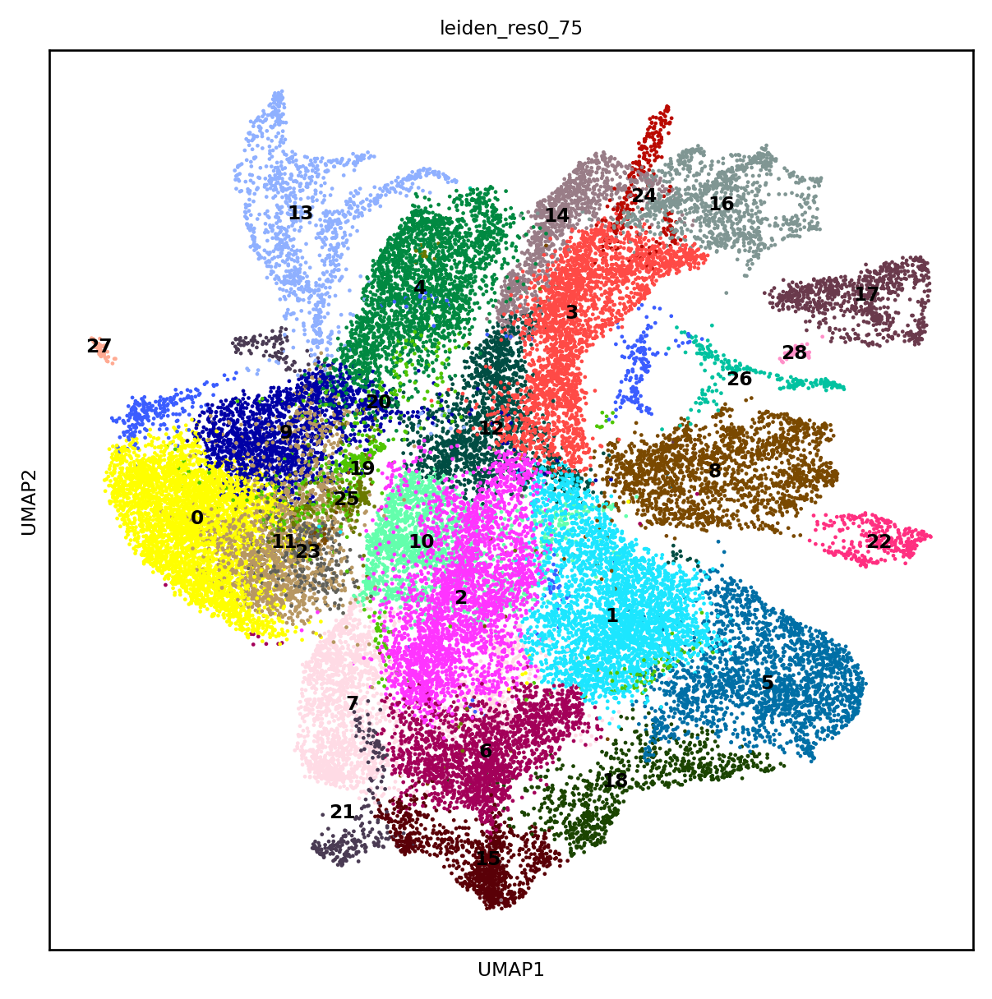

In [ ]:
sc.set_figure_params(dpi=120, figsize=[6,6], fontsize=7)

sc.pl.umap(adata, color=['leiden_res0_75'], legend_loc="on data", size = 8)

### Plot Embeddings

In [ ]:
sc.pl.umap(adata, color=['sample'], size = 15)

In [ ]:
sc.pl.umap(adata, color=['Group'], size = 20)

In [ ]:
sc.set_figure_params(dpi=120, figsize=[4,4], fontsize=7)
sc.pl.umap(adata, color=['log1p_total_counts','log1p_n_genes_by_counts'])
sc.pl.umap(adata, color=['pct_counts_ribo','pct_counts_mito'])
sc.pl.umap(adata, color=['pct_counts_in_top_50_genes', 'doublet_score'])

In [ ]:
sc.set_figure_params(dpi=120, figsize=[20,4], fontsize=7)
sc.pl.violin(adata, ['doublet_score'], jitter=0.4, groupby = 'leiden_res0_75', rotation = 90)

### Cluster markers

In [ ]:
sc.tl.rank_genes_groups(adata, 'leiden_res0_75', layer='raw', reference='rest', n_genes=100, method='wilcoxon',
                        corr_method='benjamini-hochberg', log_transformed=True)

/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:463: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result

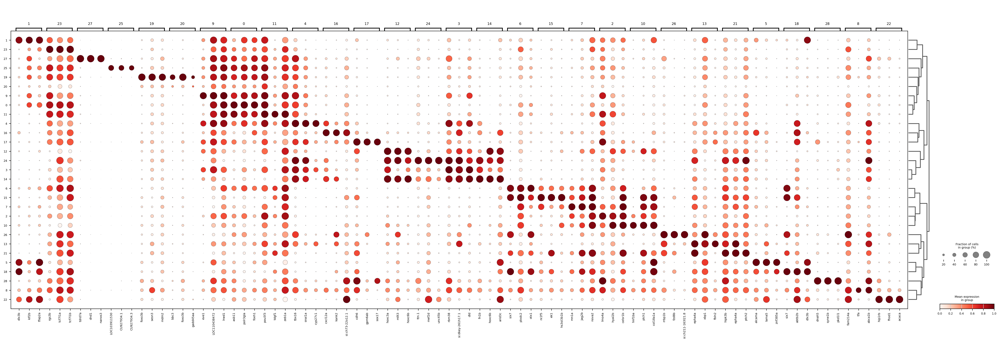

In [ ]:
sc.tl.dendrogram(adata, groupby='leiden_res0_75', use_raw=False)
sc.pl.rank_genes_groups_dotplot(adata, n_genes=3, standard_scale = 'var')

In [ ]:
# Get the number of cells per sample
cell_counts_per_sample = adata.obs['leiden_res0_75'].value_counts()

# Print the result
print(cell_counts_per_sample)

leiden_res0_75
0     4023
1     3138
2     2939
3     2632
4     2410
5     2107
6     1915
7     1902
8     1898
9     1673
10    1665
11    1549
12    1516
13    1140
14    1068
15    1039
16    1019
17     779
18     764
19     523
20     436
21     339
22     312
23     304
24     273
25     249
26     224
27      65
28      55
Name: count, dtype: int64


In [ ]:
Leidentable = dew.get_deg_table(adata, ngenes_csv=100, ngenes_disp=50)

In [ ]:
Leidentable

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28
0,asb11,dlx3b,lmo4a,rbm38,tbx16,alcama,six7,mn1a,fam214a,eve1,hnf1ba,pou5f3,hoxc3a,epha4a,fn1b,nr2f5,cxcl12a,cdh6,six7,foxo3b,bbc3,hipk3b,hip1rb,rgs3b,ttn.1,LOC103911530,rrbp1b,tdrd7a,dnah5
1,polr3gla,klf2b,hyal2b,si:dkey-261h17.1,snai1a,lama5,plxdc2,jag2b,tfa,LOC110438472,plch1,tdgf1,mllt3,xbp1,hoxc6b,ek1,kank2,gpm6ab,abtb2b,sesn3,foxo3b,epha4a,fhod1,tcf7l1a,mef2d,CU927934.1,fzd8b,dnd1,syne1b
2,foxh1,tfap2a,celsr1b,dld,cyp27c1,znf385a,otx1,nova2,abca1b,lrwd1,col18a1a,zeb1a,hoxc6b,fbln2,arid3c,hs3st3b1b,si:ch73-22o12.1,sox17,dlx3b,mdm2,gadd45aa,ptch2,acaca,tcf7l1b,unc45b,CU927934.3,si:ch211-163l21.8,nanos3,pkd1l1
3,marcksl1b,tfap2c,chrd,tbx16l,nckap5l,bcam,otx2b,mdkb,kat5b,ved,meis2b,cxcr4b,hoxc8a,noto,ephb3,ptprn2,notch2,sox32,eya1,ccng1,cdkn1a,rfx4,ppl,plekha5,myod1,lrwd1,frzb,ddx4,CABZ01055306.1
4,rgs3b,kctd15a,ctnnal1,wnt8a,aldh1a2,itga6b,sfrp1a,gli3,pimr168,pou5f3,hyal2b,foxd3,nradd,p4ha2,hoxc3a,pax6b,fn1a,gata5,prdm1a,rnf169,rbl2,shhb,znf185,xylt1,rbfox1l,pou5f3,si:dkey-269i1.4,ca15b,cftr
5,lrwd1,prdm1a,celsr1a,ephb3,wnt11f2,itga3b,fezf2,greb1l,fetub,add3b,meis3,rnf220a,hoxd3a,foxa2,LO016987.2,plxdc2,col13a1,prex1,dmbx1a,rbl2,fosab,pcdh18a,myo5b,si:ch73-274k23.1,ppargc1a,add3b,slit3,slc16a3,CABZ01076275.1
6,cxcr4b,dnmt3bb.1,col4a5,tob1a,im:7138239,rarga,pax6b,BX284638.1,pck2,inavab,map7d1a,asb11,hoxb3a,ntd5,phc2a,zbtb16b,cdh11,flrt3,zbtb16b,tp53,si:ch211-260e23.9,shha,krt5,tiam1b,hsp90aa1.1,polr3gla,znf704,h1m,bicc2
7,ctcf,yap1,sp5l,cdx1a,hspa12a,pcdh19,otx2a,ncam1a,atp2b2,bmp7a,meis2a,zic3,hoxb7a,kirrel3l,jcada,tenm4,pdgfra,plpp3,pla2g4aa,abcc5,phlda3,dact2,nrg1,pak6a,smyd1b,rgs3b,zbtb46,gra,dnah7
8,add3b,gata2a,nova2,soga1,abi1b,gata3,pkdcca,irx7,macf1a,vrtn,rfx4,mex3b,hoxb1b,shha,plp2,lhx2b,nrp2b,lzts2a,si:ch211-250c4.4,slc4a2a,LOC100537178,cdc42bpab,si:ch211-166a6.5,ctnnal1,fxr2,ctcf,pitx2,si:ch211-241j12.3,foxj1a
9,pou5f3,esrp1,si:ch211-191i18.2,nradd,vrtn,shroom4,cyp26a1,tenm4,plxna3,bmp4,tshz1,acin1b,greb1,rrbp1b,mllt3,zbtb16a,cxcl12b,asph,zbtb46,LOC100537178,rps27l,sox13,mboat1,si:ch211-285f17.1,sulf1,fbxo5,tram1,rbm7,ccdc13


In [ ]:
dew.plot_stacked_barplot(adata.obs['leiden_res0_75'], adata.obs['Group'], normalize='index', fig_width=8)

In [ ]:
Leidentable.to_csv(data_path + 'CPC_All_NormoxiaOnly_0_75leiden.csv')

In [ ]:
sc.set_figure_params(dpi=120, figsize=[4,4], fontsize=7)
sc.pl.umap(adata, color=['sox19a', 'sox2', 'tfap2c', 'gata2a', 'tbxta', 'noto', 'dnd1', 'nanos3', 'sox32', 'cdh6', 'tbx16', 'msgn1', 'ved', 'cdx4','otx2a', 'admp', 'gsc', 'chrd','dkk1b', 'fetub', 'tfa'])

In [ ]:
adata.write(data_path + "h5ad/Normoxia_Clustered.h5ad", compression = 'gzip')

A good stopping point

##Symphony ZMAP annotation

The purpose of this section is to use ZMAP as an third party reference to annotate cells.

**ZMAP reference:**

ZMAP: A single-cell meta-atlas of zebrafish embryonic development reveals a consensus hierarchy of cell identities
Nicole A. Aponte-Santiago, Yingxin Su, Daniel E. Wagner
bioRxiv 2026.03.23.713599; doi: https://doi.org/10.64898/2026.03.23.713599

**Symphony reference:**


Kang, J.B., Nathan, A., Weinand, K. et al. Efficient and precise single-cell reference atlas mapping with Symphony. Nat Commun 12, 5890 (2021). https://doi.org/10.1038/s41467-021-25957-x


In [ ]:


# print python version to screen
!python --version

# pip install software
!pip install -q fa2_modified
!pip install -q scanpy
!pip install -q adjustText==0.8 gdown==4.7.1
!pip install -q symphonypy

# import python packages
import os, sys, warnings, gc
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import symphonypy as sp


# set some ScanPy settings
sc.set_figure_params(dpi=120, figsize=[4,4], fontsize=7)
sc.settings.verbosity = 1

Python 3.12.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.8/620.8 kB 13.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 115.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 137.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive/')
data_path = '/content/drive/MyDrive/Chris/All/'  #change dir to your project folder

Mounted at /content/drive/


### Load adata_query and adata_ref

In [ ]:
# import a version of zmap, which has been truncated to 5-12 hpf stages

adata_ref = sc.read('Zmap_subset.h5ad')
adata_ref

AnnData object with n_obs × n_vars = 83849 × 2622
    obs: 'library_id', 'total_counts', 'n_genes_by_counts', 'Cluster', 'tissue', 'clust', 'tissue.figure', 'tissue.name', 'cell.cycle.class', 'zebrafish_anatomy_ontology_class', 'zebrafish_anatomy_ontology_id', 'zebrafish_anatomy_ontology_top', 'ClusterName', 'GermLayer', 'CellTypeName', 'time_id', 'study_id', 'leiden_1', 'leiden_5', 'leiden_10', 'leiden_50'
    var: 'gene_ids', 'highly_variable', 'mean', 'std'
    uns: 'harmony', 'hvg', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
adata_query = sc.read(data_path + "h5ad/Normoxia_clustered.h5ad")
adata_query

AnnData object with n_obs × n_vars = 37956 × 31655
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'n_genes', 'Group', 'Condition', 'total_counts', 'n_genes_by_counts', 'n_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'batch', 'total_counts_mt', 'pct_counts_mt', 'percent_mt2', 'leiden_res0_75'
    var: 'gene_id', 'genome', 'n_cells', 'mito', 'ribo', 'n_cells_by_counts-0', 'mean_counts-0', 'log1p_mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'log1p_total_counts-0', 'n_cells_by_counts-1', 'mean_counts-1', 'log1p_mean_counts-1', 'pct_dropout_by_counts-1', 'total_counts-1', 'log

### Map adata_query to adata_ref and transfer labels

In [ ]:
sp.tl.map_embedding(adata_query, adata_ref)
sp.tl.ingest(adata_query=adata_query, adata_ref=adata_ref)

/usr/local/lib/python3.12/dist-packages/symphonypy/tl.py:268: FutureWarning: The specified parameters ('inplace',) are no longer positional. Please specify them like `inplace=True`
  return ing.to_adata(inplace)


In [ ]:
# ZMAP timepoint label transfer
ref_labels = ['time_id']

# Subset adata_ref to a fixed # cells per timepoint
n_cells_per_timepoint = 1000
adata_ref_obs_tmp = adata_ref.obs.copy()
adata_ref_obs_tmp = adata_ref_obs_tmp.sample(frac=1) # randomize
time_ind_subset = adata_ref_obs_tmp.groupby(ref_labels).head(n_cells_per_timepoint).index # get row indices
sp.tl.transfer_labels_kNN(adata_query=adata_query, adata_ref=adata_ref[time_ind_subset], ref_labels=ref_labels)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [ ]:
# Sur2023 annotation transfer
ref_labels = ['cell.cycle.class', 'tissue.name', 'tissue.figure']
sp.tl.transfer_labels_kNN(adata_query=adata_query, adata_ref=adata_ref[~adata_ref.obs[ref_labels[0]].isna()], ref_labels=ref_labels)

In [ ]:
# Wagner2018 annotation transfer
ref_labels = ['CellTypeName', 'GermLayer', 'ClusterName']
sp.tl.transfer_labels_kNN(adata_query=adata_query, adata_ref=adata_ref[~adata_ref.obs[ref_labels[0]].isna()], ref_labels=ref_labels)

### Plot results

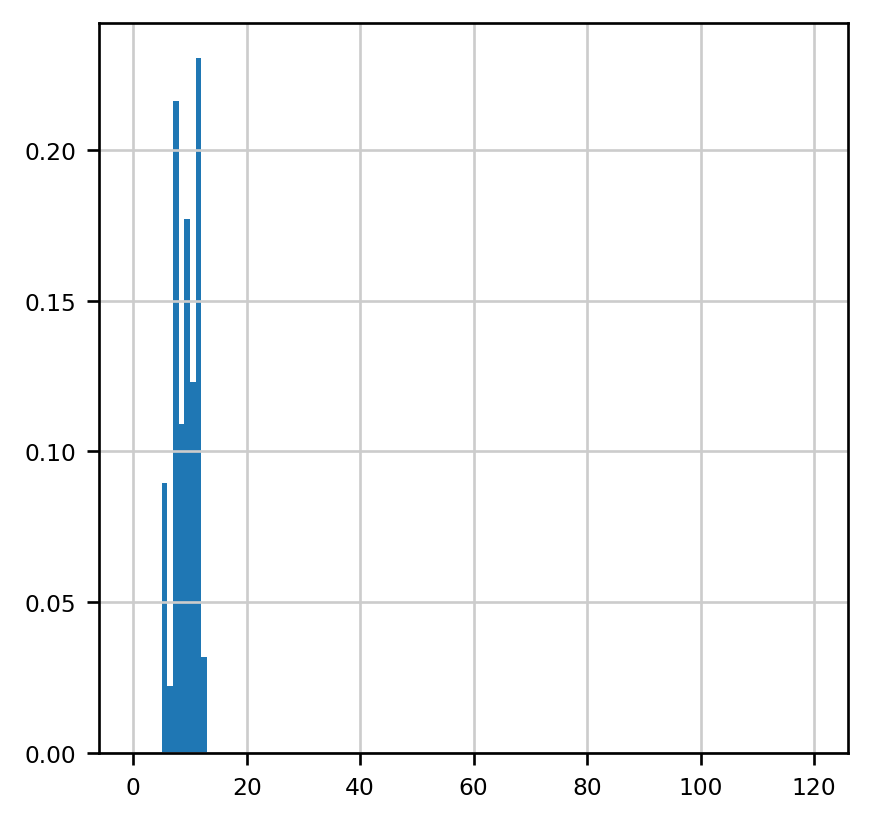

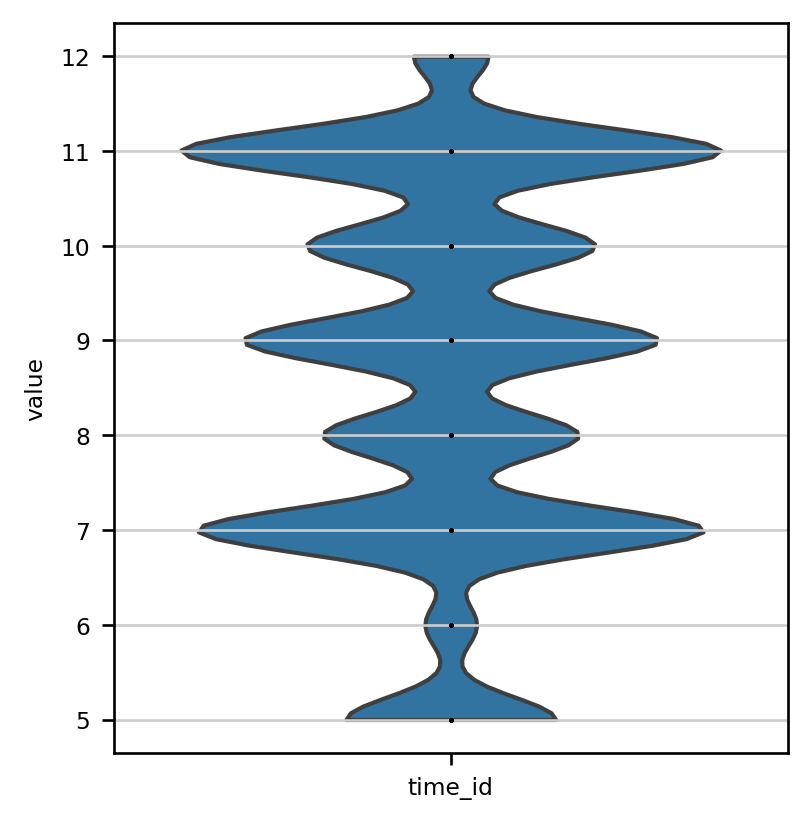

Median assigned time_id: 9.0


In [ ]:
# plot histograms of mapped time_ids
plt.hist(adata_query.obs['time_id'],bins=range(0,121,1), density=True);

sc.pl.violin(adata_query, ['time_id'], jitter=0)

# print the median assigned time_id value to screen
print('Median assigned time_id:', adata_query.obs['time_id'].median())

In [ ]:
# just move .obs labels
adata_wt = sc.read(data_path + 'h5ad/Normoxia_clustered.h5ad')

In [ ]:

# Transfer columns
adata_wt.obs['ClusterName'] = adata_query.obs['ClusterName']
adata_wt.obs['CellTypeName'] = adata_query.obs['CellTypeName']
adata_wt.obs['tissue.name'] = adata_query.obs['tissue.name']
adata_wt.obs['tissue.figure'] = adata_query.obs['tissue.figure']
adata_wt.obs['GermLayer'] = adata_query.obs['GermLayer']

In [ ]:
# export

adata_wt.write(data_path + 'h5ad/Normoxia_clustered_SymphonyAnnotated.h5ad', compression = 'gzip')

In [ ]:
adata = adata_wt.copy()

#or

#adata = sc.read(data_path + 'h5ad/Normoxia_clustered_SymphonyAnnotated.h5ad')

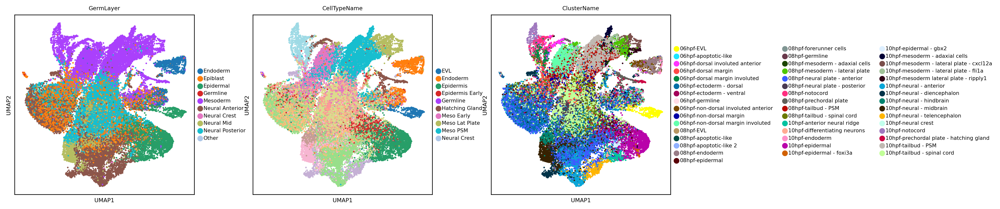

In [ ]:
clusters = [ 'GermLayer','CellTypeName','ClusterName', ]

sc.pl.umap(adata, color=clusters, size = 15)

In [ ]:
clusters = ['leiden_res0_75']

sc.pl.umap(adata, color=clusters, size = 15)

In [ ]:
## manually import confusion matrix function from https://github.com/wagnerde/scTools-py/tree/master

## this avoids mayhem

import sklearn

def get_confusion_matrix(labels_A, labels_B,
                         normalize=True,
                         title=None,
                         reorder_columns=True,
                         reorder_rows=True,
                         cmap=plt.cm.Blues,
                         overlay_values=False,
                         vmin=None,
                         vmax=None,
                         show_plot=True,
                         return_df=False,
                         figsize=4):
    '''
    Plots a confusion matrix comparing two sets labels.
    '''

    # Filter labels if value is missing from either set
    nan_flag = labels_A.isnull() | labels_B.isnull()
    labels_A = labels_A[~nan_flag]
    labels_B = labels_B[~nan_flag]

    # Get all the unique values for each set of labels
    labels_A_unique = np.unique(labels_A.astype('string'))
    labels_B_unique = np.unique(labels_B.astype('string'))

    # Compute confusion matrix
    cm = sklearn.metrics.confusion_matrix(labels_A, labels_B)
    non_empty_rows = cm.sum(axis=0)!=0
    non_empty_cols = cm.sum(axis=1)!=0
    cm = cm[:,non_empty_rows]
    cm = cm[non_empty_cols,:]
    cm = cm.T

    # Normalize by rows (label B)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Set title, colorbar, and axis names
    if normalize:
        colorbar_label = 'Fraction Overlap'
        if not title:
            title = 'Normalized confusion matrix'
    else:
        colorbar_label = '# Overlaps'
        if not title:
            title = 'Confusion matrix, without normalization'

    # If available, get the label category names for plotting
    if hasattr(labels_A, 'name'):
        labels_A_name = labels_A.name
    else:
        labels_A_name = 'Label A'
    if hasattr(labels_B, 'name'):
        labels_B_name = labels_B.name
    else:
        labels_B_name = 'Label B'

    # If requested, reorder the rows and columns by best match
    if reorder_columns:
        top_match_c = np.argmax(cm, axis=0)
        reordered_columns = np.argsort(top_match_c)
        cm=cm[:,reordered_columns]
        labels_A_unique_sorted = labels_A_unique[reordered_columns]
    else:
        labels_A_unique_sorted = labels_A_unique

    if reorder_rows:
        top_match_r = np.argmax(cm, axis=1)
        reordered_rows = np.argsort(top_match_r)
        cm=cm[reordered_rows,:]
        labels_B_unique_sorted = labels_B_unique[reordered_rows]
    else:
        labels_B_unique_sorted = labels_B_unique

    # If requested, generate heatmap and format figure axes
    if show_plot:

        plt.rcParams['axes.grid'] = False
        fig, ax = plt.subplots(figsize=(figsize,figsize))
        im = plt.imshow(cm, interpolation='nearest', cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_aspect('equal')
        ax.set_xticks(np.arange(cm.shape[1]))
        ax.set_yticks(np.arange(cm.shape[0]))
        ax.set_title(title)
        ax.set_ylabel(labels_B_name)
        ax.set_xlabel(labels_A_name)
        ax.set_xticklabels(labels_A_unique_sorted, rotation=90, ha='center', minor=False)
        ax.set_yticklabels(labels_B_unique_sorted)

        # Format colorbar
        cb=ax.figure.colorbar(im, ax=ax, shrink=0.5)
        #cb.ax.tick_params(labelsize=10)
        cb.ax.set_ylabel(colorbar_label, rotation=90)

        # If requested, loop over data dimensions and create text annotations
        if overlay_values:
            fmt = '.1f' if normalize else 'd'
            thresh = cm.max() / 2.
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(j, i, format(cm[i, j], fmt),
                            ha="center", va="center",
                            color="white" if cm[i, j] > thresh else "black",
                            size=8)

    # If requested, return dataframe mapping top A match for each B
    if return_df:

        if reorder_rows:
            labels_A_mapped = labels_A_unique_sorted[top_match_r]
        else:
            labels_A_mapped = labels_A_unique_sorted

        mapping = pd.DataFrame(data=labels_A_mapped, index=labels_B_unique, columns=['top_match'])

        # Sort the index labels, if possible
        orig_list = labels_B_unique
        orig_list_digits = [s for s in orig_list if s.isdigit()]
        if len(orig_list)==len(orig_list_digits):
            mapping.index = mapping.index.astype(int)
            mapping = mapping.sort_index()

        return mapping


plot_confusion_matrix = get_confusion_matrix # alias to legacy function name

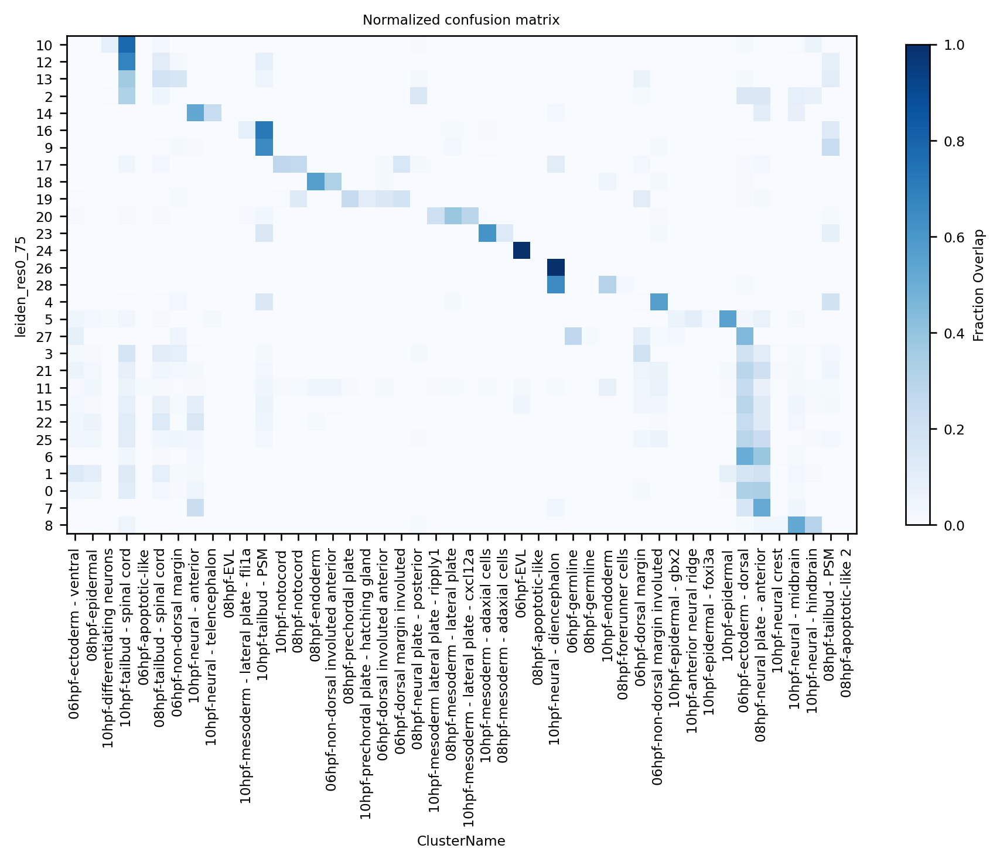

In [ ]:
plot_confusion_matrix(adata.obs['ClusterName'], adata.obs['leiden_res0_75'], figsize=9)

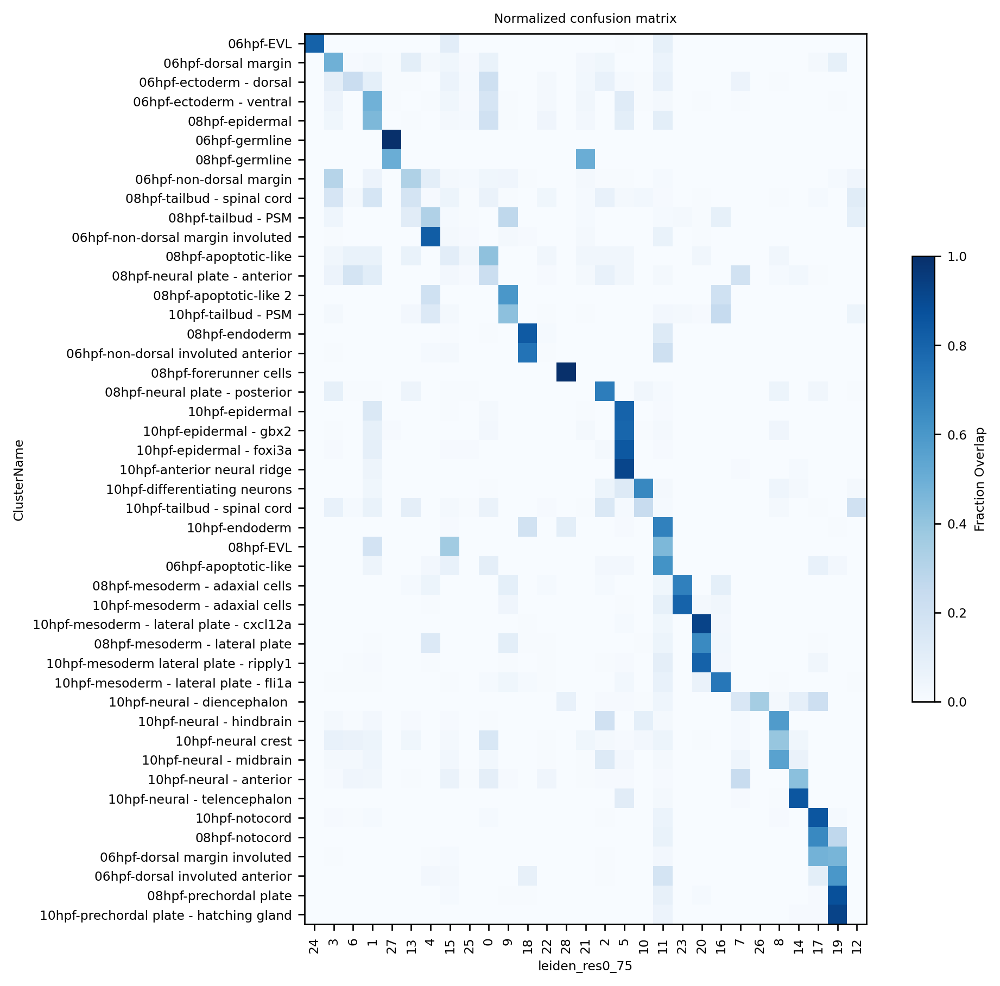

In [ ]:
plot_confusion_matrix(adata.obs['leiden_res0_75'], adata.obs['ClusterName'], figsize=9)

In [ ]:
plot_confusion_matrix(adata.obs['CellTypeName'], adata.obs['leiden_res0_75'], figsize=9)

In [ ]:
plot_confusion_matrix(adata.obs['leiden_res0_75'], adata.obs['CellTypeName'], figsize=9)

### Cluster Annotation


/usr/local/lib/python3.10/dist-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


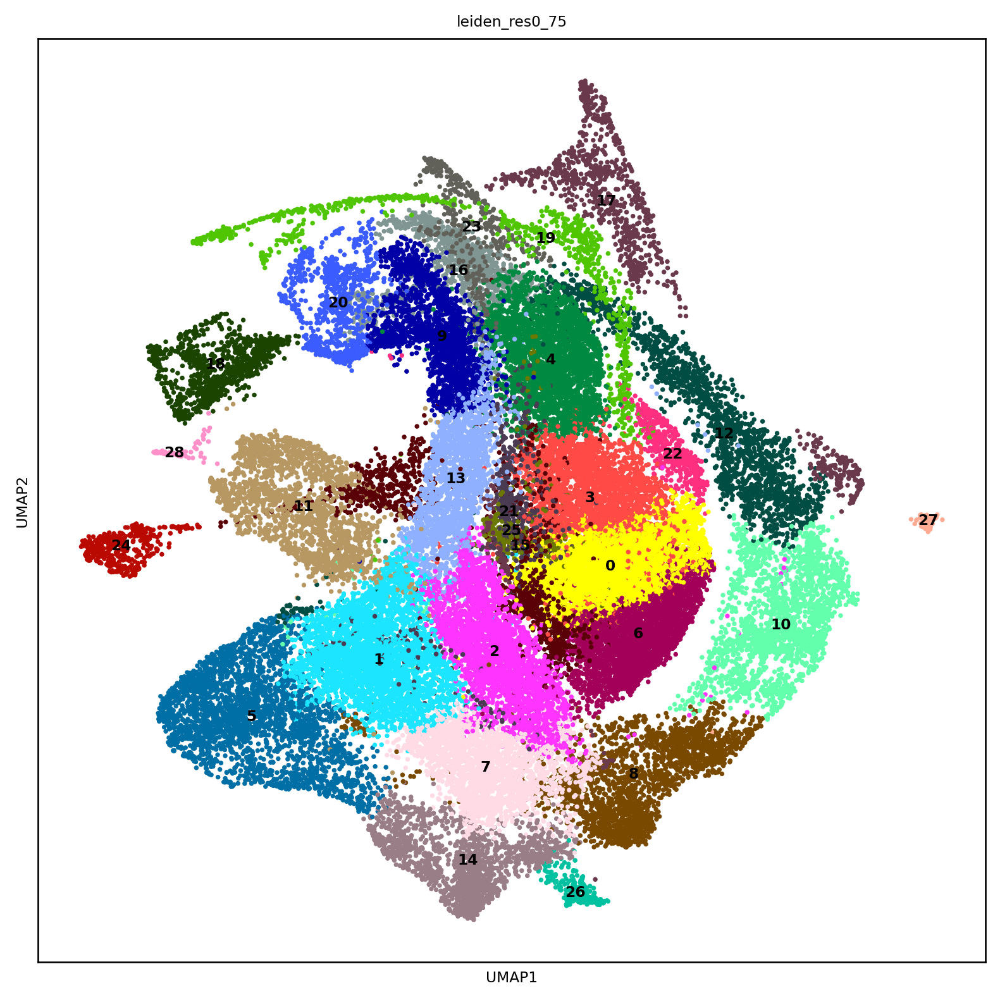

In [ ]:
# using an older output for demonstration purposes below

sc.set_figure_params(dpi=120, figsize=[8,8], fontsize=7)
sc.pl.umap(adata, color = 'leiden_res0_75', size = 20, legend_loc = 'on data')

In [ ]:
sc.set_figure_params(dpi=120, figsize=[4,4], fontsize=7)
sc.pl.umap(adata, color = ['bambia', 'tfap2c','chrd','otx1', 'cdx4', 'foxh1', 'polr3gla', 'marcksl1b', 'asb1', 'cxcr4b', 'asb11', 'pou5f3', 'stm', 'rgs3b','zic3'])

In [ ]:
dew.plot_stacked_barplot(adata.obs['leiden_res0_75'], adata.obs['Group'], normalize='index', fig_width=8)

In [ ]:
# Example: Load your data frame containing cluster names and markers.

# This marker gene list is from Wagner, D. E., Weinreb, C., Collins, Z. M., Briggs, J. A., Megason, S. G., & Klein, A. M. (2018). Single-cell mapping of gene expression landscapes and lineage in the zebrafish embryo. Science, 360(6392), 981–987.
# from the marker gene supp table

data = pd.read_csv('/DEWMarkers.csv', sep=',')

# Iterate over each row in your data
for idx, row in data.iterrows():
    cluster_name = row['ClusterName']
    markers = row[1:].dropna().tolist()  # Extract markers, excluding 'ClusterName'

    # Filter markers to include only those that are in adata.var_names
    valid_markers = [marker for marker in markers if marker in adata.var_names]

    # Check if there are valid markers to plot
    if valid_markers:
        # Generate the dotplot for each cluster
        sc.pl.dotplot(
            adata,
            valid_markers,
            groupby='leiden_res0_75',
            dendrogram=True,
            swap_axes=True,
            title=cluster_name
        )

In [ ]:

# Get unique values from 'leiden_res0_75' column
unique_values = adata.obs['leiden_res0_75'].unique()

# Initialize an empty list to store results
results = []

# Loop over each unique value
for value in unique_values:
    # Subset the DataFrame based on 'leiden_res0_75'
    subset = adata.obs[adata.obs['leiden_res0_75'] == value]

    # Determine the most common string in 'ClusterName'
    most_common = subset['ClusterName'].value_counts().idxmax()

    # Append the result to the list
    results.append({'Leiden Cluster': value, 'Most Common ClusterName': most_common})

# Convert the list to a pandas DataFrame
results_df = pd.DataFrame(results)

# Ensure that 'Leiden Cluster' is treated as numeric for sorting
results_df['Leiden Cluster'] = pd.to_numeric(results_df['Leiden Cluster'], errors='coerce')

# Sort the DataFrame by 'Leiden Cluster' in ascending order
results_df_sorted = results_df.sort_values(by='Leiden Cluster', ascending=True)

# Display the sorted table
results_df_sorted


,Leiden Cluster,Most Common ClusterName
25,0,08hpf-neural plate - anterior
18,1,08hpf-neural plate - anterior
7,2,10hpf-tailbud - spinal cord
26,3,06hpf-ectoderm - dorsal
24,4,06hpf-non-dorsal margin involuted
8,5,10hpf-epidermal
27,6,06hpf-ectoderm - dorsal
15,7,08hpf-neural plate - anterior
1,8,10hpf-neural - midbrain
17,9,10hpf-tailbud - PSM


In [ ]:


# Get unique values from 'ClusterName' column
unique_cluster_names = adata.obs['ClusterName'].unique()

# Initialize an empty list to store results
results = []

# Loop over each unique ClusterName
for cluster_name in unique_cluster_names:
    # Subset the DataFrame based on 'ClusterName'
    subset = adata.obs[adata.obs['ClusterName'] == cluster_name]

    # Determine the most common Leiden cluster in 'leiden_res0_75'
    most_common_leiden = subset['leiden_res0_75'].value_counts().idxmax()

    # Append the result to the list
    results.append({'ClusterName': cluster_name, 'Most Common Leiden Cluster': most_common_leiden})

# Convert the list to a pandas DataFrame
results_df = pd.DataFrame(results)

# Sort the DataFrame by 'ClusterName' in ascending order
results_df_sorted = results_df.sort_values(by='ClusterName', ascending=True)

# Display the sorted table
results_df_sorted


,ClusterName,Most Common Leiden Cluster
4,06hpf-EVL,24
39,06hpf-apoptotic-like,11
38,06hpf-dorsal involuted anterior,19
37,06hpf-dorsal margin,3
36,06hpf-dorsal margin involuted,17
3,06hpf-ectoderm - dorsal,6
17,06hpf-ectoderm - ventral,1
41,06hpf-germline,27
31,06hpf-non-dorsal involuted anterior,18
32,06hpf-non-dorsal margin,13


In [ ]:

# Get unique values from 'leiden_res0_75' column
unique_values = adata.obs['leiden_res0_75'].unique()

# Initialize an empty list to store results
results = []

# Loop over each unique value
for value in unique_values:
    # Subset the DataFrame based on 'leiden_res0_75'
    subset = adata.obs[adata.obs['leiden_res0_75'] == value]

    # Determine the most common string in 'CellTypeName'
    most_common = subset['CellTypeName'].value_counts().idxmax()

    # Append the result to the list
    results.append({'Leiden Cluster': value, 'Most Common CellTypeName': most_common})

# Convert the list to a pandas DataFrame
results_df = pd.DataFrame(results)

# Ensure that 'Leiden Cluster' is treated as numeric for sorting
results_df['Leiden Cluster'] = pd.to_numeric(results_df['Leiden Cluster'], errors='coerce')

# Sort the DataFrame by 'Leiden Cluster' in ascending order
results_df_sorted = results_df.sort_values(by='Leiden Cluster', ascending=True)

# Display the sorted table
results_df_sorted


,Leiden Cluster,Most Common CellTypeName
25,0,Neural Early Ant
18,1,Epidermis Early
7,2,Neural Spinal Cord
26,3,Meso Early
24,4,Meso Early
8,5,Epidermis
27,6,Neural Early
15,7,Neural Early Ant
1,8,Neural Midbrain
17,9,Meso PSM


In [ ]:


# Get unique values from 'CellTypeName' column
unique_cluster_names = adata.obs['CellTypeName'].unique()

# Initialize an empty list to store results
results = []

# Loop over each unique CellTypeName
for cluster_name in unique_cluster_names:
    # Subset the DataFrame based on 'CellTypeName'
    subset = adata.obs[adata.obs['CellTypeName'] == cluster_name]

    # Determine the most common Leiden cluster in 'leiden_res0_75'
    most_common_leiden = subset['leiden_res0_75'].value_counts().idxmax()

    # Append the result to the list
    results.append({'CellTypeName': cluster_name, 'Most Common Leiden Cluster': most_common_leiden})

# Convert the list to a pandas DataFrame
results_df = pd.DataFrame(results)

# Sort the DataFrame by 'CellTypeName' in ascending order
results_df_sorted = results_df.sort_values(by='CellTypeName', ascending=True)

# Display the sorted table
results_df_sorted


,CellTypeName,Most Common Leiden Cluster
4,EVL,24
6,Endoderm,18
7,Epidermis,5
13,Epidermis Early,1
17,Germline,27
12,Hatching Gland,19
16,Meso Early,4
11,Meso Lat Plate,20
0,Meso PSM,9
14,Neural Crest,8


In [ ]:
markergenes = pd.read_csv('CPC_All_WTonly_0_75leiden_gentle.csv')
markergenes

,Unnamed: 0,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28
0,0,foxh1,tfap2a,lmo4a,pou5f3,tbx16,alcama,asb11,six7,mn1a,fn1b,hnf1ba,tfa,hoxc3a,cdx1a,ek1,rgs3b,fn1b,epha4a,gpm6ab,xbp1,col13a1,foxo3b,bbc3,ttn.1,hip1rb,LOC103911530,nkx2.1,tdrd7a,cftr
1,1,polr3gla,dlx3b,celsr1b,rasgef1ba,cyp27c1,znf385a,tcf7l1a,plxdc2,jag2b,tbx16l,plch1,fetub,hoxc6b,cdx4,ptprn2,slc38a3b,arid3c,fndc3ba,cdh6,foxa3,fn1a,sesn3,gadd45aa,mef2d,fhod1,CU927934.1,tet3,nanos3,dnah5
2,2,marcksl1b,klf2b,chrd,LOC110438472,snai1a,lama5,stm,otx1,nova2,si:dkey-261h17.1,col18a1a,pcxb,mllt3,nradd,pax6b,plekha5,hoxc6b,plod2,sox17,ndr2,cxcl12a,mdm2,foxo3b,unc45b,acaca,CU927934.3,ek1,dnd1,syne1b
3,3,asb11,kctd15a,hyal2b,lrwd1,nckap5l,fat2,rgs3b,otx2b,mdkb,soga1,hyal2b,pck2,hoxd3a,greb1,zbtb16b,tcf7l1a,hoxc3a,ppp1r14c,sox32,kirrel3l,pdgfra,rbl2,cdkn1a,myod1,znf185,pou5f3,epha4a,ca15b,pkd1l1
4,4,cxcr4b,tfap2c,ctnnal1,etv4,aldh1a2,rarga,aldob,fezf2,gli3,msgn1,meis2b,cdh6,hoxc8a,hoxc3a,tenm4,tiam1b,hoxb3a,rrbp1b,gata5,rrbp1b,cdh11,ccng1,rbl2,ppargc1a,krt5,lrwd1,ptch2,ddx4,CABZ01055306.1
5,5,lrwd1,prdm1a,col4a5,foxd5,hspa12a,pcdh19,sall4,sfrp1a,greb1l,rbm38,rfx4,macf1a,nradd,wnt5b,six7,si:ch73-274k23.1,mllt3,foxa2,prex1,frzb,snai1b,rnf169,fosab,sulf1,ppl,fbxo5,hipk3b,slc16a3,bicc2
6,6,cited4b,yap1,nova2,add3b,zswim5,grhl2b,mex3b,pkdcca,ncam1a,lpar1,map7d1a,abca1b,hoxb7a,wnt8a,zic1,gmds,plp2,shha,flrt3,nrip1a,cxcl12b,abcc5,phlda3,fxr2,mboat1,ctcf,epha7,gra,ccdc13
7,7,pou5f3,esrp1,meis2b,vrtn,flrt3,tp63,pou5f3,otx2a,BX284638.1,hspa12a,meis3,mia2,hoxa9a,lypd6b,zbtb16a,unkl,samd10b,creb3l1,plpp3,elovl6,lsp1,LOC100537178,si:ch211-260e23.9,smyd1b,nrg1,add3b,fezf2,si:ch211-241j12.3,foxj1a
8,8,ctcf,gata2a,znf423,ctcf,kirrel3l,itga3b,zic3,pax6b,tenm4,ephb3,meis2a,apobb.1,hoxb1b,itgb5,nr2f5,eif3ha,sox5,col15a1a,lzts2a,lhx1a,notch2,slc4a2a,LOC100537178,myf5,myo5b,polr3gla,nkx2.4b,h1m,dnah7
9,9,add3b,foxi1,mdkb,cxcr4b,abi1b,bcam,sfrp1a,cyp26a1,msi1,LO016987.2,celsr1b,plxna3,arid3c,hoxc8a,plxdc2,furina,lpar1,itga6a,phldb1b,fbln2,kank2,tanc1b,gadd45bb,rbfox1l,afap1l2,ddx5,ephb3a,ppp1r12a,daam1b


In [ ]:
anon_to_new = {
    '0': 'Ectoderm ventral',
    '1': 'Epidermis 8hpf',
    '2': 'Neural plate posterior',
    '3': 'Dorsal margin',
    '4': 'Non dorsal margin involuted',
    '5': 'Epidermis 10hpf',
    '6': 'Ectoderm dorsal',
    '7': 'Neural plate anterior',
    '8': 'Neural midhindbrain',
    '9': 'Tailbud PSM',
    '10': 'Tailbud spinal cord 1',
    '11': 'YSL',
    '12': 'Tailbud spinal cord 2',
    '13': 'Tailbud spinal cord 8hpf',
    '14': 'Neural anterior',
    '15': 'Not sure 1',
    '16': 'Tailbud PSM',
    '17': 'Notochord',
    '18': 'Endoderm',
    '19': 'Prechordal plate',
    '20': 'Mesoderm lateral plate',
    '21': 'Apototic like 1',
    '22': 'Apoptotic like 2',
    '23': 'Mesoderm adaxial cells',
    '24': 'EVL',
    '25': 'Not sure 2',
    '26': 'Neural diencephalon',
    '27': 'Germline',
    '28': 'Forerunner cells'
}

adata.obs['Cluster'] = (
    adata.obs['leiden_res0_75']
    .map(anon_to_new)
    .astype('category')
)

In [ ]:
sc.set_figure_params(dpi=120, figsize=[10,10], fontsize=7)

In [ ]:
sc.pl.umap(adata, color = "Cluster", size = 20)

/usr/local/lib/python3.10/dist-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


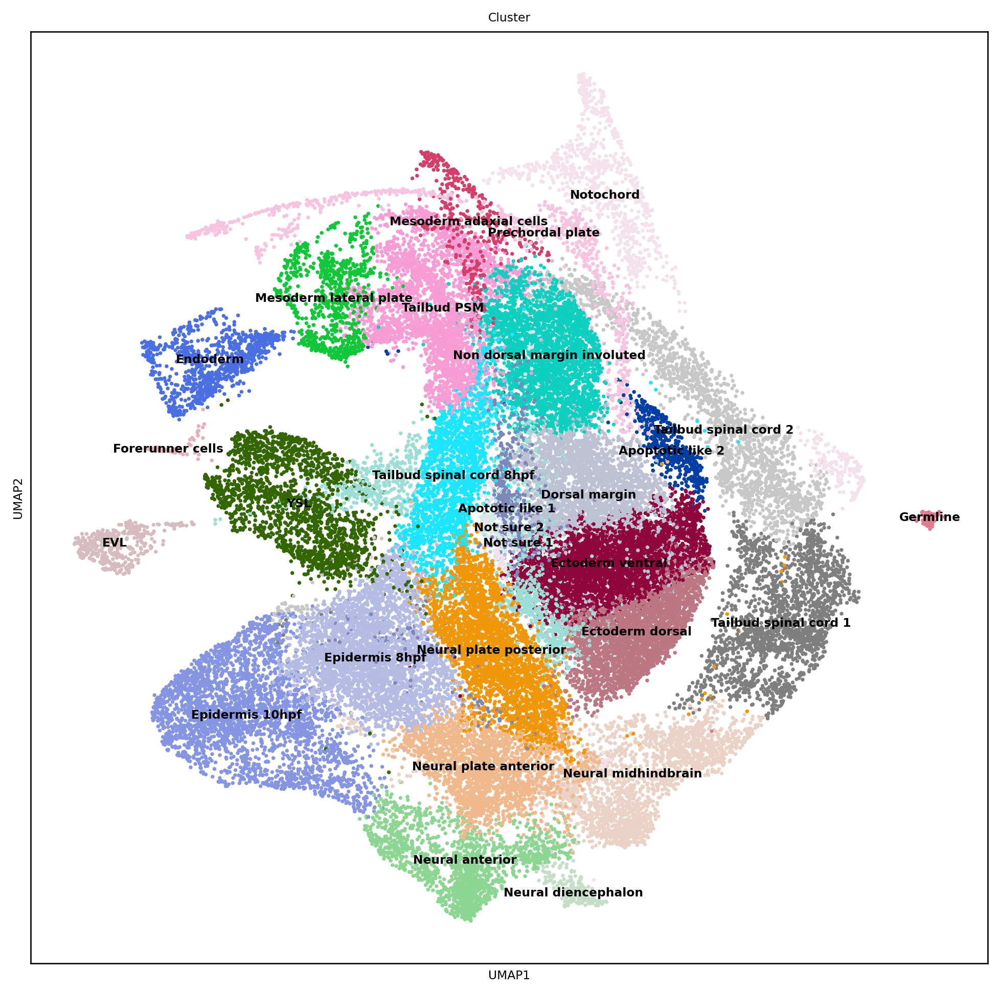

In [ ]:
sc.pl.umap(adata, color = "Cluster", size = 20, legend_loc = "on data")

In [ ]:
adata.write(data_path + 'h5ad/Normoxia_Annotated.h5ad', compression = 'gzip')

another good stopping point

## Celltypist

Now that we have annotated our normoxia leiden clusters, we can train a classifier on it to annotate the hypoxia and reoxy cells.

Only the main steps and key parameters are introduced in this notebook. Refer  to detailed [Usage](https://github.com/Teichlab/celltypist#usage) if you want to learn more.

Adapted from the celltypist tutorials

In [ ]:
# Mount google drive

from google.colab import drive
drive.mount('/content/drive/')
data_path = '/content/drive/MyDrive/Chris/All/'  #change dir to your project folder

Mounted at /content/drive/


In [ ]:
!pip install celltypist

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 124.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 141.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 153.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 115.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing in

In [ ]:
import scanpy as sc
import celltypist
from celltypist import models
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


### Load in h5ads

In [ ]:
# load in minimally processed, h5ad of full dataset
adata_query = sc.read(data_path + 'h5ad/Preprocessed.h5ad')

In [ ]:
# load in processed and annoated dataset, only normoxic cells should be present here, only used for labels.
adata_ref = sc.read(data_path + 'h5ad/Normoxia_Annotated.h5ad')

In [ ]:
# here we're transfering the previously determined annotations and filtering those that have a label

common_indices = adata_query.obs.index.intersection(adata_ref.obs.index)

# Transfer the "Cluster" labels from adata_ref to adata_query for common indices
adata_query.obs.loc[common_indices, 'Cluster'] = adata_ref.obs.loc[common_indices, 'Cluster']

# Remove cells with NaN values in the 'Cluster' column of adata_query
adata_query = adata_query[~adata_query.obs['Cluster'].isna()].copy()

In [ ]:
# This is the dataset that we want to use for classifying
adata_processed = sc.read(data_path + 'h5ad/Preprocessed.h5ad')

### Generate custom model

Generating a custom model and transferring labels from the model to the query data.

In [ ]:
adata_2000 = adata_query.copy()

In [ ]:
## cell typist wants a different normalization, have to adjust

# Re-normalize tpm_nolog (1e6) down to 1e4, then log1p
adata_2000.X = adata_2000.layers['raw_nolog'].copy()  # start from raw counts

sc.pp.normalize_total(adata_2000, target_sum=1e4, inplace=True)  # normalize to 10k
adata_2000.X = np.log1p(adata_2000.X)  # log1p transform

# Verify it passes celltypist's check (should be ~10000)
print(np.expm1(adata_2000.X[0]).sum())  # should print ~10000

10000.0


Derive a custom model by training the data using the [celltypist.train](https://celltypist.readthedocs.io/en/latest/celltypist.train.html) function.

In [ ]:
# The `cell_type` in `adata_2000.obs` will be used as cell type labels for training.
new_model = celltypist.train(adata_2000, labels = 'Cluster', n_jobs = 10, feature_selection = True)

Refer to the function [celltypist.train](https://celltypist.readthedocs.io/en/latest/celltypist.train.html) for what each parameter means, and to the [usage](https://github.com/Teichlab/celltypist#usage) for details of model training.

In [ ]:
# Save the model.
new_model.write(data_path + 'Normoxia_model.pkl')

You can load this model by `models.Model.load`.

In [ ]:
new_model = models.Model.load(data_path + 'Normoxia_model.pkl')

Next, we use this model to predict the query dataset

In [ ]:
adata_400 = adata_processed.copy()

In [ ]:
adata_400.obs['Group'].unique()

['Anoxia_2hrs_WT', 'Normoxia_10hpf_WT', 'Normoxia_6hpf_WT', 'Normoxia_8hpf_WT', 'Reoxy_2hrs_WT']
Categories (5, object): ['Anoxia_2hrs_WT', 'Normoxia_6hpf_WT', 'Normoxia_8hpf_WT',
                         'Normoxia_10hpf_WT', 'Reoxy_2hrs_WT']

In [ ]:
# Re-normalize tpm_nolog (1e6) down to 1e4, then log1p
adata_400.X = adata_400.layers['raw_nolog'].copy()  # start from raw counts

sc.pp.normalize_total(adata_400, target_sum=1e4, inplace=True)  # normalize to 10k
adata_400.X = np.log1p(adata_400.X)  # log1p transform

# Verify it passes celltypist's check (should be ~10000)
print(np.expm1(adata_400.X[0]).sum())  # should print ~10000

10000.0


In [ ]:

# just specify the model path (recommended as this ensures the model is intact every time it is loaded).
predictions = celltypist.annotate(adata_400, model = data_path + 'Normoxia_model.pkl', majority_voting = True)

In [ ]:
adata = predictions.to_adata()

In [ ]:
# Quick umap for visualization
sc.tl.umap(adata)

In [ ]:
adata.obs

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,...,predicted_doublet,batch,total_counts_mt,pct_counts_mt,percent_mt2,leiden,predicted_labels,over_clustering,majority_voting,conf_score
13_01_72__s1-16,Anoxia_2hrs_WT_1,GRCZ11Law,3659,15547,24817,13,1,72,B1,A1,...,False,16,33.0,0.212260,0.002123,3,Non dorsal margin involuted,0,Non dorsal margin involuted,0.226813
13_02_35__s1-16,Anoxia_2hrs_WT_1,GRCZ11Law,2412,9247,14396,13,2,35,B1,A2,...,False,16,21.0,0.227101,0.002271,9,Non dorsal margin involuted,5,Non dorsal margin involuted,0.321799
13_02_84__s1-16,Anoxia_2hrs_WT_1,GRCZ11Law,3791,18308,29747,13,2,84,B1,A2,...,False,16,49.0,0.267643,0.002676,0,Ectoderm dorsal,12,Ectoderm dorsal,0.996676
13_02_88__s1-16,Anoxia_2hrs_WT_1,GRCZ11Law,1919,4811,7388,13,2,88,B1,A2,...,False,16,9.0,0.187071,0.001871,0,Ectoderm ventral,16,Ectoderm ventral,0.934560
13_02_91__s1-16,Anoxia_2hrs_WT_1,GRCZ11Law,3576,14388,22620,13,2,91,B1,A2,...,False,16,40.0,0.278009,0.002780,0,Ectoderm ventral,19,Ectoderm ventral,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24_91_70__s8-47,Reoxy_2hrs_WT_4,GRCZ11Law,2950,7959,12439,24,91,70,B12,H7,...,False,47,45.0,0.565398,0.005654,1,Neural plate anterior,166,Neural plate anterior,0.999886
24_93_06__s8-47,Reoxy_2hrs_WT_4,GRCZ11Law,2786,6619,10182,24,93,6,B12,H9,...,False,47,21.0,0.317268,0.003173,1,Neural plate posterior,300,Neural plate posterior,0.750398
24_93_82__s8-47,Reoxy_2hrs_WT_4,GRCZ11Law,2722,5244,8325,24,93,82,B12,H9,...,False,47,0.0,0.000000,0.000000,20,Neural plate posterior,306,YSL,0.587604
24_95_23__s8-47,Reoxy_2hrs_WT_4,GRCZ11Law,3174,10599,16964,24,95,23,B12,H11,...,False,47,27.0,0.254741,0.002547,1,Epidermis 8hpf,139,Dorsal margin,0.164778


In [ ]:
sc.set_figure_params(dpi=120, figsize=[8,8], fontsize=7)

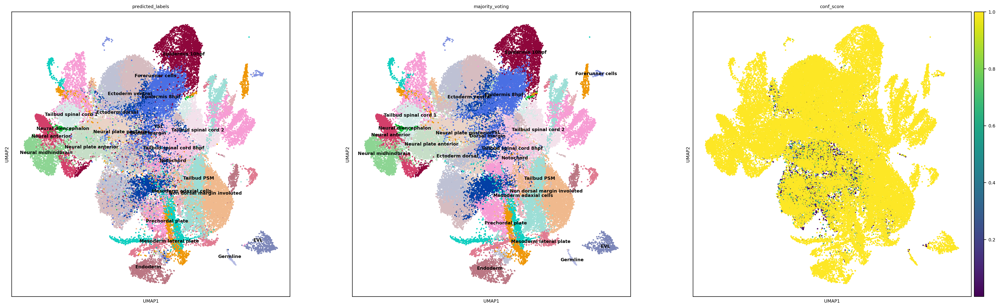

In [ ]:
sc.pl.umap(adata, color = ['predicted_labels', 'majority_voting', 'conf_score'], legend_loc = 'on data', size = 20)

In [ ]:
sc.pl.umap(adata, color = ['Group', 'Condition','majority_voting', ], size = 20)

In [ ]:
sc.set_figure_params(dpi=120, figsize=[5,5], fontsize=7)
variable = list(adata.obs['Group'].unique())
for Cluster in variable:
    sc.pl.umap(adata, color='Group', groups=[Cluster], size = 10)

In [ ]:
sc.set_figure_params(dpi=120, figsize=[5,5], fontsize=7)
variable = list(adata.obs['majority_voting'].unique())
for Cluster in variable:
    sc.pl.umap(adata, color='majority_voting', groups=[Cluster], size = 10)

In [ ]:
celltypist.dotplot(predictions, use_as_reference = 'predicted_labels', use_as_prediction = 'majority_voting')

### Examine expression of cell type-driving genes

Each model can be examined in terms of the driving genes for each cell type. Note these genes are only dependent on the model, say, the training dataset.

In [ ]:

model = models.Model.load(model = data_path + 'Normoxia_model.pkl')

In [ ]:
model.cell_types

array(['Dorsal margin', 'EVL', 'Ectoderm dorsal', 'Ectoderm ventral',
       'Endoderm', 'Epidermis 10hpf', 'Epidermis 8hpf',
       'Forerunner cells', 'Germline', 'Mesoderm adaxial cells',
       'Mesoderm lateral plate', 'Neural anterior', 'Neural diencephalon',
       'Neural midhindbrain', 'Neural plate anterior',
       'Neural plate posterior', 'Non dorsal margin involuted',
       'Notochord', 'Prechordal plate', 'Tailbud PSM',
       'Tailbud spinal cord 1', 'Tailbud spinal cord 2',
       'Tailbud spinal cord 8hpf', 'YSL'], dtype=object)

Extract the top three driving genes of `Mast cells` using the [extract_top_markers](https://celltypist.readthedocs.io/en/latest/celltypist.models.Model.html#celltypist.models.Model.extract_top_markers) method.

In [ ]:
top_3_genes = model.extract_top_markers("Notochord", 3)
top_3_genes

array(['twist2', 'irx3a', 'foxa2'], dtype=object)

In [ ]:
# Check expression of the three genes in the training set.
sc.pl.violin(adata_2000, top_3_genes, groupby = 'Cluster', rotation = 90)

In [ ]:
# Check expression of the three genes in the query set.
# Here we use `majority_voting` from CellTypist as the cell type labels for this dataset.
sc.pl.violin(adata_400, top_3_genes, groupby = 'majority_voting', rotation = 90)

In [ ]:
all = list(adata_400.obs['majority_voting'].unique())
for i in all:
  print('The top markers for', i, 'are', model.extract_top_markers(i, 5))

The top markers for Non dorsal margin involuted are ['mespab' 'FP102169.1' 'efnb2b' 'aplnrb' 'LOC110438232']
The top markers for Ectoderm dorsal are ['her3' 'zic3' 'tcf7l1a' 'f2rl1.2' 'rgs3b']
The top markers for Ectoderm ventral are ['yap1' 'krt5' 'magi2b' 'XLOC_043975' 'tfap2a']
The top markers for YSL are ['erlin2' 'ehbp1l1b' 'a2ml' 'zgc:136410' 'pla2g12b']
The top markers for Dorsal margin are ['lmo4a' 'msx1b' 'notum1a' 'adamts18' 'hes6']
The top markers for Prechordal plate are ['zgc:174153' 'ctslb' 'BX322603.1' 'bhlha15' 'gfi1b']
The top markers for Neural plate posterior are ['chrd' 'znf503' 'pax3a' 'gas2l1' 'meis2b']
The top markers for Endoderm are ['sox17' 'sox32' 'VSTM2B' 'abtb2a' 'gpm6ab']
The top markers for Forerunner cells are ['rerglb' 'FP102122.3' 'ccdc181' 'syt6b' 'wdr93']
The top markers for Neural plate anterior are ['six7' 'pax6b' 'nkx2.9' 'gsc' 'sfrp1a']
The top markers for Tailbud spinal cord 8hpf are ['foxd3' 'hoxc3a' 'hoxc8a' 'znf710a' 'myf5']
The top markers f

In [ ]:
adata.write(data_path + 'h5ad/All_Annotated.h5ad', compression = 'gzip')